In [2]:
import tensorflow as tf

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
  "dog_cat_photos/train",
  image_size=(224, 224),
  label_mode="binary",
  batch_size=32,
  shuffle=True
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
  "dog_cat_photos/test",
  image_size=(224, 224),
  label_mode="binary",
  batch_size=32,
  shuffle=False
)

Found 300 files belonging to 2 classes.
Found 100 files belonging to 2 classes.


In [3]:
list(train_dataset.as_numpy_iterator())[0]

2026-01-23 02:51:25.521025: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


(array([[[[220.       , 220.       , 220.       ],
          [220.0424   , 220.0424   , 220.0424   ],
          [226.40402  , 226.40402  , 226.40402  ],
          ...,
          [101.94423  , 101.94423  , 101.94423  ],
          [106.96658  , 106.96658  , 106.96658  ],
          [107.       , 107.       , 107.       ]],
 
         [[219.98885  , 219.98885  , 219.98885  ],
          [220.03122  , 220.03122  , 220.03122  ],
          [226.3891   , 226.3891   , 226.3891   ],
          ...,
          [101.88401  , 101.88401  , 101.88401  ],
          [106.90188  , 106.90188  , 106.90188  ],
          [106.935265 , 106.935265 , 106.935265 ]],
 
         [[218.31473  , 218.31473  , 218.31473  ],
          [218.35338  , 218.35338  , 218.35338  ],
          [224.15073  , 224.15073  , 224.15073  ],
          ...,
          [ 92.8513   ,  92.8513   ,  92.8513   ],
          [ 97.19653  ,  97.19653  ,  97.19653  ],
          [ 97.22545  ,  97.22545  ,  97.22545  ]],
 
         ...,
 
         [[1

In [4]:
class_names = train_dataset.class_names
class_names

['cat', 'dog']

2026-01-23 02:58:14.426531: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


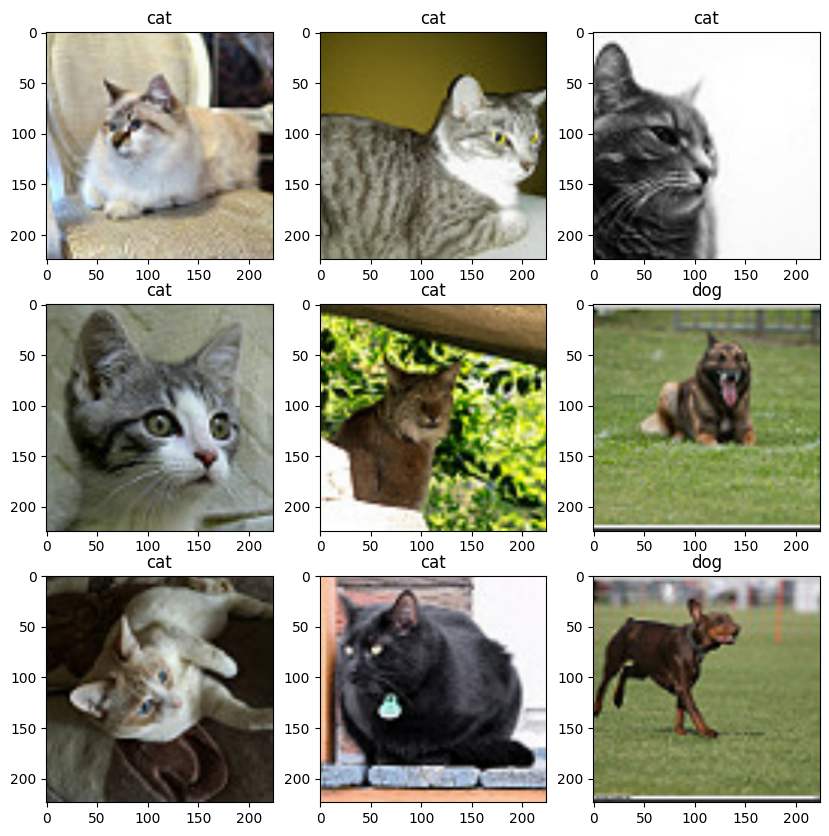

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [9]:
# 画像の水増しをする関数の定義
def flip_left_right(image, label):   # 左右反転
    image = tf.image.flip_left_right(image)
    return image, label

def flip_up_down(image, label):      # 上下反転
    image = tf.image.flip_up_down(image)
    return image, label

def rot90(image, label):             # 反時計回りに90度回転
    image = tf.image.rot90(image)
    return image, label

def rot180(image, label):            # 反時計回りに180度回転
    image = tf.image.rot90(image, k=2)
    return image, label

def rot270(image, label):            # 反時計回りに270度回転
    image = tf.image.rot90(image, k=3)
    return image, label

In [10]:
# 画像の水増し処理の実行
train_dataset_lr     = train_dataset.map(flip_left_right)
train_dataset_ud     = train_dataset.map(flip_up_down)
train_dataset_rot90  = train_dataset.map(rot90)
train_dataset_rot180 = train_dataset.map(rot180)
train_dataset_rot270 = train_dataset.map(rot270)

In [11]:
# 水増ししたデータを訓練データに追加する
train_dataset = train_dataset.concatenate(train_dataset_lr)
train_dataset = train_dataset.concatenate(train_dataset_ud)
train_dataset = train_dataset.concatenate(train_dataset_rot90)
train_dataset = train_dataset.concatenate(train_dataset_rot180)
train_dataset = train_dataset.concatenate(train_dataset_rot270)

In [12]:
# データをシャッフルする
train_dataset = train_dataset.shuffle(32)

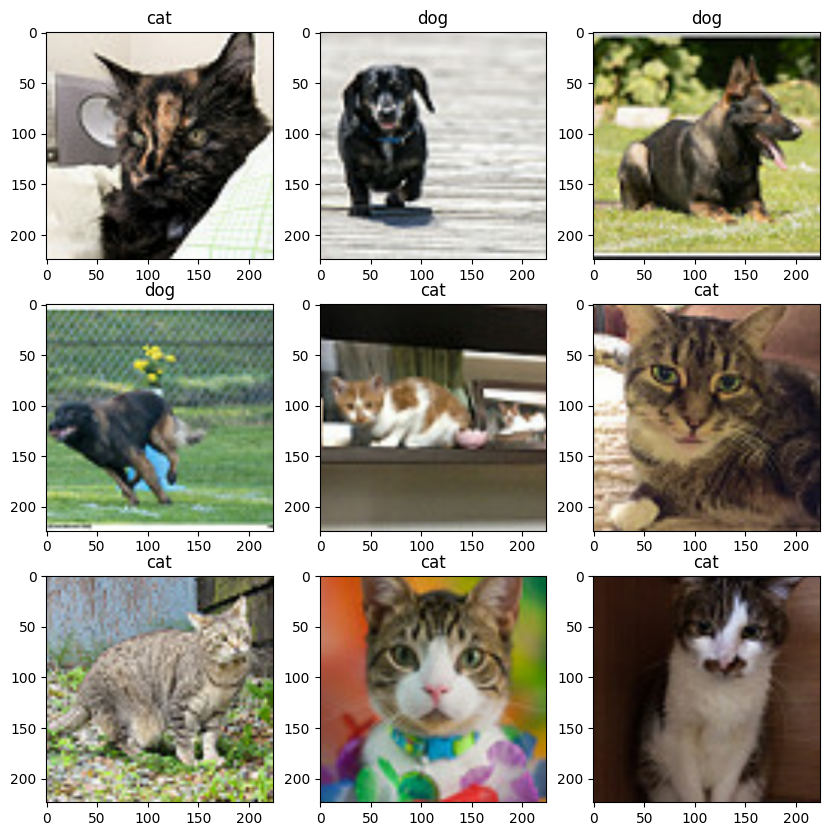

In [13]:
# 訓練データの一部を表示して確認
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [25]:
# MobileNetV2モデルを作成する
input_layer = tf.keras.Input(shape=(224, 224, 3))   # 入力層
l_layer = tf.keras.applications.mobilenet_v2.preprocess_input(input_layer)   # 前処理（正規化）をする層

base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(
    input_shape=(224, 224, 3),
    input_tensor=l_layer,
    include_top=False,
    weights="imagenet",
    pooling='avg'
)
base_model.trainable = False

In [26]:
# Dense層を追加する
output_layer = tf.keras.layers.Dense(1, activation='sigmoid')


In [27]:
# base_modelに先ほどのDense層を追加したモデルを作成する
model = tf.keras.Sequential([
    base_model,
    output_layer
])

In [28]:
# modelをcompileする
model.compile(optimizer="adam",
              loss='binary_crossentropy',
              metrics=["accuracy"])

In [29]:
# modelに学習させる
model.fit(train_dataset, epochs=20)


Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 168ms/step - accuracy: 0.8311 - loss: 0.3959
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 160ms/step - accuracy: 0.9217 - loss: 0.2191
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 158ms/step - accuracy: 0.9472 - loss: 0.1629
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 159ms/step - accuracy: 0.9589 - loss: 0.1357
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 162ms/step - accuracy: 0.9694 - loss: 0.1141
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 159ms/step - accuracy: 0.9717 - loss: 0.1008
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 160ms/step - accuracy: 0.9767 - loss: 0.0897
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 160ms/step - accuracy: 0.9806 - loss: 0.0793
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 159ms/step - accuracy: 0.9844 - loss: 0.0716
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 164ms/step - accuracy: 0.9856 - loss: 0.0646
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 158ms/step - accuracy: 0.9889 - loss: 0.0592
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 10

In [30]:
# テストデータで分類を実行する
pred_data = model.predict(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 251ms/step


In [31]:
pred_data

array([[1.59298885e-04],
       [1.38237505e-04],
       [4.68907638e-05],
       [2.88031460e-03],
       [5.17368258e-04],
       [2.27480647e-04],
       [5.46697993e-04],
       [6.38173311e-04],
       [1.09548027e-05],
       [3.51454131e-04],
       [6.13501397e-05],
       [3.53787094e-03],
       [6.26133429e-03],
       [2.94240599e-04],
       [7.09969900e-05],
       [6.00211524e-06],
       [8.07244796e-05],
       [6.68773253e-04],
       [4.75315796e-03],
       [3.98281449e-03],
       [7.95508642e-03],
       [8.44528526e-02],
       [4.08292515e-03],
       [4.72626212e-04],
       [2.18936533e-01],
       [8.85952613e-04],
       [1.47110899e-03],
       [1.65708677e-03],
       [1.00281546e-02],
       [1.95603032e-04],
       [1.70136488e-03],
       [7.94298589e-01],
       [2.92503682e-04],
       [1.32595317e-03],
       [4.37580701e-03],
       [9.57445741e-01],
       [4.95435391e-03],
       [4.57624812e-03],
       [2.06933450e-02],
       [3.15539131e-04],


In [32]:
# evaluate()でモデルの性能を評価する
model.evaluate(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.9600 - loss: 0.0786


[0.07858964055776596, 0.9599999785423279]